# Particle in a Box in an External Electric Field

In the section on [approximate methods](https://qchem.qc-edu.org/ApproximateMethods.html), we extensively explore the solutions for the particle in a box in an external field. One of the systems we explored was a charged [particle-in-a-box in an external electric field](https://qchem.qc-edu.org/ApproximateMethods.html#example-particle-in-a-box-with-a-sloped-bottom), with the Hamiltonian,

$$
\hat{H} = -\tfrac{1}{2}\nabla^2 + V(x)
$$

where

$$
V(x) = \left\{
    \begin{array}{ll}
        Fx & x  \in (-1, 1) \\
        \infty & x \notin (-1, 1)
    \end{array}
\right.
$$

where the parameter $F$ controls the strength of the electric field. We will use the basis set expansion again here, but using a very simple polynomial basis, where `NumPy` built-in methods are very useful. This will allow us to get very accurate results very efficiently.

## Expansion in a Basis
A wavefunction can be expanded in any complete basis,

$$
\Psi(x) = \sum_{k=0}^{\infty} c_k \phi_k(x)
$$

For real problems, of course, one can choose only a finite number of basis functions,

$$
\Psi(x) \approx \sum_{k=0}^{N_{\text{basis}}} c_k \phi_k(x)
$$

but as the number of basis functions, $N_{\text{basis}}$, increases, results should become increasingly accurate.

Substituting this expression for the wavefunction into the time-independent Schr&ouml;dinger equation,

\begin{align}
\hat{H} \Psi(x) &= E \Psi(x) \\
\hat{H} \sum_{k=0}^{\infty} c_k \phi_k(x) &= E \sum_{k=0}^{\infty} c_k \phi_k(x) \\
 \sum_{k=0}^{\infty} c_k \hat{H} \phi_k(x) &= E \sum_{k=0}^{\infty} c_k \phi_k(x)
\end{align}

In the second line we use the fact that the Hamiltonian is a linear operator.
Multiplying on the left by $\left(\phi_j(x) \right)^*$ and integrating over all space, we obtain

$$
 \sum_{k=0}^{\infty} \left[\int \left(\phi_j(x) \right)^* \hat{H} \phi_k(x) dx \right] c_k
 = E \sum_{k=0}^{\infty}\left[ \int \left(\phi_j(x) \right)^* \phi_k(x) dx\right] c_k
$$

At this stage we usually define the Hamiltonian matrix, $\mathbf{H}$, as the matrix with elements

$$
h_{jk} = \int \left(\phi_j(x) \right)^* \hat{H} \phi_k(x) dx
$$

and the overlap matrix, $\mathbf{S}$ as the matrix with elements

$$
s_{jk} = \int \left(\phi_j(x) \right)^* \phi_k(x) dx
$$

If the basis is orthonormal, then the overlap matrix is equal to the identity matrix, $\mathbf{S} = \mathbf{I}$ and its elements are therefore given by the Kronecker delta, $s_{jk} = \delta_{jk}$.

## Generalized Eigenproblem: The Secular Equation
The Schr&ouml;dinger equation therefore can be written as a [generalized matrix eigenvalue problem](https://en.wikipedia.org/wiki/Eigendecomposition_of_a_matrix#Generalized_eigenvalue_problem):

$$
\mathbf{Hc}=E\mathbf{Sc}
$$

or, in element-wise notation, as:

$$
 \sum_{k=0}^{\infty} h_{jk} c_k
 = E \sum_{k=0}^{\infty} s_{jk} c_k
$$

In the special case where the basis functions are orthogonormal, $\mathbf{S} = \mathbf{I}$ and this is an ordinary [matrix eigenvalue problem](https://en.wikipedia.org/wiki/Eigenvalues_and_eigenvectors#Eigenvalues_and_eigenvectors_of_matrices),

$$
\mathbf{Hc}=E\mathbf{c}
$$

or, in element-wise notation, as:

$$
 \sum_{k=0}^{\infty} h_{jk} c_k
 = E c_j
$$

In the context of quantum chemistry, the generalized eigenvalue problem

$$
\mathbf{Hc}=E\mathbf{Sc}
$$

is called the *secular equation*. This is a historical nomenclature, associated with the fact that the eigenvalues of the (generalized) eigenproblem are the roots of the characteristic polynomial,

$$
p(E) = \text{det}\left(\mathbf{H} - E \mathbf{S} \right)
$$

The equation $p(E) = 0$ was often called the "secular equation" in the early days of linear algebra, a terminology inherited from the utility of this sort of equation in describing secular (i.e., long time-scale) perturbations of planetary motion.




To solve the secular equation:
1. Choose a basis, $\{|\phi_k\rangle \}$ and a basis-set size, $N_{\text{basis}}$
1. Evaluate the matrix elements of the Hamiltonian and the overlap matrix

$$
\begin{align}
h_{jk} &= \int \left(\phi_j(x) \right)^* \hat{H} \phi_k(x) dx  \qquad \qquad 0 \le j,k \le N_{\text{basis}} \\
s_{jk} &= \int \left(\phi_j(x) \right)^* \phi_k(x) dx
\end{align}
$$

3. Solve the generalized eigenvalue problem

$$
 \sum_{k=0}^{\infty} h_{jk} c_k
 = E \sum_{k=0}^{\infty} s_{jk} c_k
$$

**Because of the variational principle, the lowest eigenvalue will always be greater than or equal to the true ground-state energy.**

## Polynomial basis

We can expand this trial wave function using a basis of polynomial functions. The polynomials are a complete basis, but it isn't obvious how to force the boundary conditions that $\phi_k(-1) = \phi_k(1) = 0$ to be satisfied. To do this, in the course notes, we used [polynomials like](https://qchem.qc-edu.org/ApproximateMethods.html#example-for-the-particle-in-a-box) $(x-1)(x+1)x^k$ and the [Jacobi polynomials](https://qchem.qc-edu.org/ApproximateMethods.html#particle-in-a-box-with-jacobi-polynomials), $(x-1)(x+1)J_k^{(2,2)}(x)$.

Here we will use

$$
\phi_k(x) = (1-x)(1+x)T_k(x)
$$

where $T_k(x)$ denote the [Chebyshev Polynomials](https://en.wikipedia.org/wiki/Chebyshev_polynomials), which are often used in numerical work because they provide close approximations to the [minimax polynomial](https://en.wikipedia.org/wiki/Minimax_approximation_algorithm), that is, the polynomial that makes the minimizes the maximum error when one fits a function to a polynomial expansion.

The Chebyshev polynomials are defined by the [3-term recursion relation](https://en.wikipedia.org/wiki/Orthogonal_polynomials#Recurrence_relation),

\begin{align}
T_0(x) &= 1 \\
T_1(x) &= x \\
T_{k+1}(x) = 2x T_k(x) - T_{k-1}(x)
\end{align}

It would be very annoying to evaluate the integrals $h_{jk}$ and $s_{jk}$ for these basis functions analytically (though it is quite easy as such types of analysis go, due to the plethora of exact identities for the Chebyshev polynomials) but, fortunately we don't need to do this: the remarkable software ecosystem of Python will do the math for us.

To generate the basis functions, we will use the [polynomial class](https://numpy.org/doc/stable/reference/routines.polynomials.polynomial.html) implemented in [NumPy](https://numpy.org/). Conveniently, this defines polynomials, by default, on the interval $-1 < x < 1$, which is exactly the interval we are interested in for this problem.





In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial

from scipy.integrate import quad
from scipy.linalg import eigh
from scipy.optimize import minimize
from numpy.polynomial import Chebyshev as T

def get_basis(n):
    """
    Return the N+1 basis functions for k = 0, 1, ..., n. The basis functions
    have the form
        \phi_k(x) = (1-x)(1+x)T_k(x)

    Parameters
    ----------
    n: int
        n+1 is the number of basis functions. N must be a positive integer.

    Returns: A polynomial basis.
    """
    if n < 1:
        raise ValueError("n must be at least 1")

    # p1 is a polynomial (x-1) and p2 is a polynomial (x+1)
    # We (for reasons of numerical stability) opt to rewrtie the polynomials
    #    in terms of their Chebyshev expansion, which is done
    #    using the .convert(kind=T)
    # T.basis(k) is the kth Chebyshev polynomial (as a polynomial object)
    p1 = Polynomial([-1,1]).convert(kind=T)
    p2 = Polynomial([1, 1]).convert(kind=T)
    phi = [p1*p2*T.basis(k) for k in range(n+1)]

    return phi

<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_560/1322961697.py:14: SyntaxWarning: invalid escape sequence '\p'
  \phi_k(x) = (1-x)(1+x)T_k(x)


The key integrals we will define are:

$$
t_{jk} = -\tfrac{1}{2} \int_{-1}^{1} \phi_j(x) \tfrac{d^2}{dx^2} \phi_k(x) \, dx
$$

$$
v_{jk} = \int_{-1}^{1} \phi_j(x) V(x) \phi_k(x) \, dx
$$

$$
s_{jk} = \int_{-1}^{1} \phi_j(x) \phi_k(x) \, dx
$$

In this case, $V(x) = F\cdot x$. Our basis functions and our Hamiltonian are real so we don't need to worry about complex conjugation.

## &#x1f469;&#x1f3fd;&#x200d;&#x1f4bb; Assignment: Complete the following notebook.

To do this, complete the code blocks indicated by `### START YOUR CODE HERE` and `### END YOUR CODE HERE` .

The detailed steps you'll follow are:

1. Complete the function `compute_s` that returns the overlap matrix.
1. Complete the function `compute_v` that returns the potential energy matrix.
1. Complete the function `solve_secular_eq` that solves the secular equation.
1. Complete the function `compute_polarizabilities` that computes the (hyper)polarizabilities and dipole moment.
1. Plot the energy as a function of basis-set size and field.
1. Plot the wavefunction; do this for several different fields and build some intuition for how the results change.
1. Upload your notebook and confirm its correctness. The marking scheme is provided at the end of this document.

In [2]:
def potential(f):
    """
    Define the potential as a polynomial object, with strength f.

    In this case the potential is V = f * x .

    Parameters
    ----------
    f: strength of the applied electric field.
    """

    return f*Polynomial([0,1]).convert(kind=T)

def compute_t(phi):
    """
    Returns the kinetic energy matrix for the basis polynomials phi

    Parameters
    ----------
    phi: Polynomial array of basis functions
    """

    # Start by filling the kinetic energy matrix with zeros.
    n = len(phi)
    t = np.zeros((n, n))

    # Populate the kinetic energy matrix
    for j in range(n):
        for k in range(n):
            # Take the second derivative of the second basis function and
            # multiply it by the first basis function, then multiply by -1/2
            phij_d2_phik = -1./2 * phi[j] * phi[k].deriv(2)
            # Do the *indefinite* integral
            integral = phij_d2_phik.integ()
            # Evaluate the definite integral by taking the difference of the
            # polynomial evaluated at two points.
            t[j,k] = integral(1.0) - integral(-1.0)
    return t

def compute_s(phi):
    """
    Returns the overlap matrix for the basis polynomials phi

    Parameters
    ----------
    phi: Polynomial array of basis functions
    """

    # Start by filling the overlap matrix with zeros.
    n = len(phi)
    s = np.zeros((n, n))

    # Populate the overlap matrix
    for j in range(n):
        for k in range(n):
    ### START YOUR CODE HERE
            # Form the product polynomial
            phij_phik = phi[j]*phi[k]
            # Do the *indefinite* integral
            integral = phij_phik.integ()
            # Evaluate the definite integral by taking the difference of the
            # polynomial evaluated at two points.
            s[j,k] = integral(1.0) - integral(-1.0)
    ### END YOUR CODE HERE
    return s

def compute_v(phi,f):
    """
    Returns the potential energy matrix for the basis polynomials phi

    Parameters
    ----------
    phi: Polynomial array of basis functions
    """

    # Start by filling the potential matrix with zeros.
    n = len(phi)
    v = np.zeros((n, n))

    # Populate the overlap matrix
    for j in range(n):
        for k in range(n):
    ### START YOUR CODE HERE
            # Form the product polynomial
            phij_v_phik = phi[j] * potential(f) * phi[k]
            # Do the *indefinite* integral
            integral = phij_v_phik.integ()
            # Evaluate the definite integral by taking the difference of the
            # polynomial evaluated at two points.
            v[j,k] = integral(1.0)-integral(-1.0)
    ### END YOUR CODE HERE
    return v

def solve_secular_eq(phi,f):
    """
    Returns the eigenvalues and eigenvectors of the secular equation, with
    a basis of polynomials specified by phi and a perturbation strength f.

    Parameters
    ----------
    phi: Polynomial array of basis functions
    f: strength of perturbation
    """

    # Start by filling the potential matrix with zeros.
    n = len(phi)
    s = np.zeros((n, n))
    H = np.zeros((n, n))

    ### START YOUR CODE HERE:
    # Compute the overlap matrix, kinetic energy matrix, and potential energy matrix
    s = compute_s(phi)
    t = compute_t(phi)
    v = compute_v(phi,f)

    # Compute the Hamiltonian matrix.
    h=t+v

    # Solve the generalized eigenvalue problem using np.linalg.eigh
    # return the eigenvectors and eigenvalues of eigenvectors and eigenvalues as c and E, respectively,
    E, c = eigh(h, s, subset_by_index=(0, n-1))
    return E,c
    ### END YOUR CODE HERE

def get_wavefunction(phi,c):
    """
    Return a Polynomial object representing the trial wavefunction expanded
    in the basis defined by phi with coefficients c,

         \psi(x) = \sum_k=0^N c_k \phi_k(x)

    Parameters:
    ----------
    c :: a vector of N+1 wavefunction coefficients.
    phi :: a vector of polynomial basis functions.
    """
    return sum([c[k]*phi[k] for k in range(len(c))])

def get_energies(n,f):
    """
    A convenient function just to return the eigenenergies for a given
    basis set size, N, and perturbation strength F.

         \psi(x) = \sum_k=0^N c_k \phi_k(x)
    """
    phi = get_basis(n)
    eigenvalues, eigenvectors = solve_secular_eq(phi,f)

    return eigenvalues

<>:130: SyntaxWarning: invalid escape sequence '\p'
<>:144: SyntaxWarning: invalid escape sequence '\p'
<>:130: SyntaxWarning: invalid escape sequence '\p'
<>:144: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_560/1295200842.py:130: SyntaxWarning: invalid escape sequence '\p'
  \psi(x) = \sum_k=0^N c_k \phi_k(x)
/tmp/ipykernel_560/1295200842.py:144: SyntaxWarning: invalid escape sequence '\p'
  \psi(x) = \sum_k=0^N c_k \phi_k(x)


We can now compute the energy of the ground state, and compare it to known results for certain field strengths.

Specifically, we know that

\begin{align}
F(\tfrac{1}{16}) &=  1.23356 \text{ a.u.} \\
F(\tfrac{25}{8}) &= 0.9063 \text{ a.u.}
\end{align}

In [3]:
phi = get_basis(10)
F = 1./16
E, c = solve_secular_eq(phi,F)
print("Energy for field strength F=1/16 is ",E[0])
F = 25./8
E, c = solve_secular_eq(phi,F)
print("Energy for field strength F=25/8 is ",E[0])

Energy for field strength F=1/16 is  1.2335633952295424
Energy for field strength F=25/8 is  0.9063121281446671


Once we have confirmed that our code seems sensible, we want to show how the eigenenergies change with field strength. The next plotting cell does this.

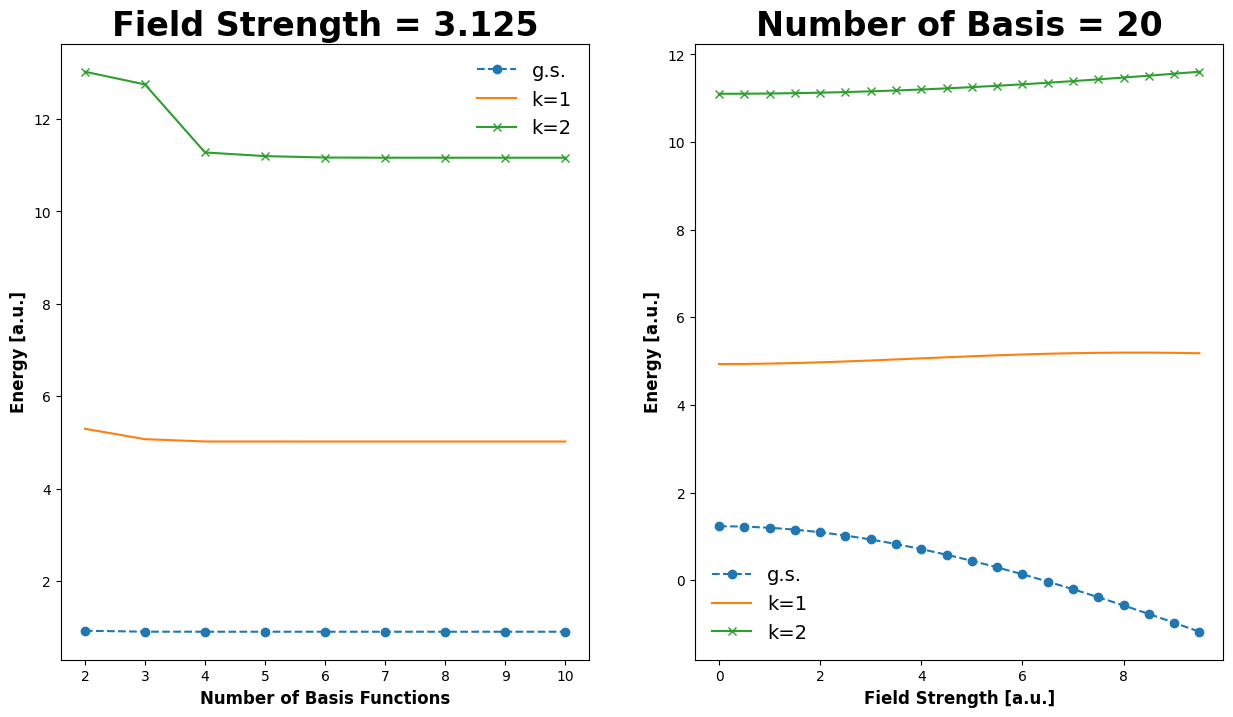

In [4]:
# user-specified parameters
field = 25.0 / 8
nbasis = 20

# plot basis set convergence of energy estimates at a given field
# ---------------------------------------------------------------

# plot basis set convergence of energy estimates at a given field
# ---------------------------------------------------------------

# evaluate first three eigenvalues for a range of basis functions at a given field
n_values = np.arange(2, 11, 1)
e_0 = np.array([get_energies(n,field)[0] for n in n_values])
e_1 = np.array([get_energies(n,field)[1] for n in n_values])
e_2 = np.array([get_energies(n,field)[2] for n in n_values])

# evaluate energy for a range of fields at a given basis
f_values = np.arange(0.0, 10., 0.5)
e_0_f = np.array([get_energies(nbasis,f)[0] for f in f_values])
e_1_f = np.array([get_energies(nbasis,f)[1] for f in f_values])
e_2_f = np.array([get_energies(nbasis,f)[2] for f in f_values])

plt.rcParams['figure.figsize'] = [15, 8]
fig, axes = plt.subplots(1, 2)
# fig.suptitle("Basis Set Convergence of Particle-in-a-Box with Chebyshev", fontsize=24, fontweight='bold')

for index, axis in enumerate(axes.ravel()):
    if index == 0:
        # plot approximate eigenvalues at a fixed field
        axis.plot(n_values, e_0, marker='o', linestyle='--', label='g.s.')
        axis.plot(n_values, e_1, marker='', linestyle='-', label='k=1')
        axis.plot(n_values, e_2, marker='x', linestyle='-', label='k=2')
        # set axes labels
        axis.set_xlabel("Number of Basis Functions", fontsize=12, fontweight='bold')
        axis.set_ylabel("Energy [a.u.]", fontsize=12, fontweight='bold')
        axis.set_title(f"Field Strength = {field}", fontsize=24, fontweight='bold')
        axis.legend(frameon=False, fontsize=14)
    else:
        # plot approximate energy at a fixed basis
        axis.plot(f_values, e_0_f, marker='o', linestyle='--', label='g.s.')
        axis.plot(f_values, e_1_f, marker='', linestyle='-', label='k=1')
        axis.plot(f_values, e_2_f, marker='x', linestyle='-', label='k=2')
        # set axes labels
        axis.set_xlabel("Field Strength [a.u.]", fontsize=12, fontweight='bold')
        axis.set_ylabel("Energy [a.u.]", fontsize=12, fontweight='bold')
        axis.set_title(f"Number of Basis = {nbasis}", fontsize=24, fontweight='bold')
        axis.legend(frameon=False, fontsize=14)

plt.show()

Now we plot the orbitals.

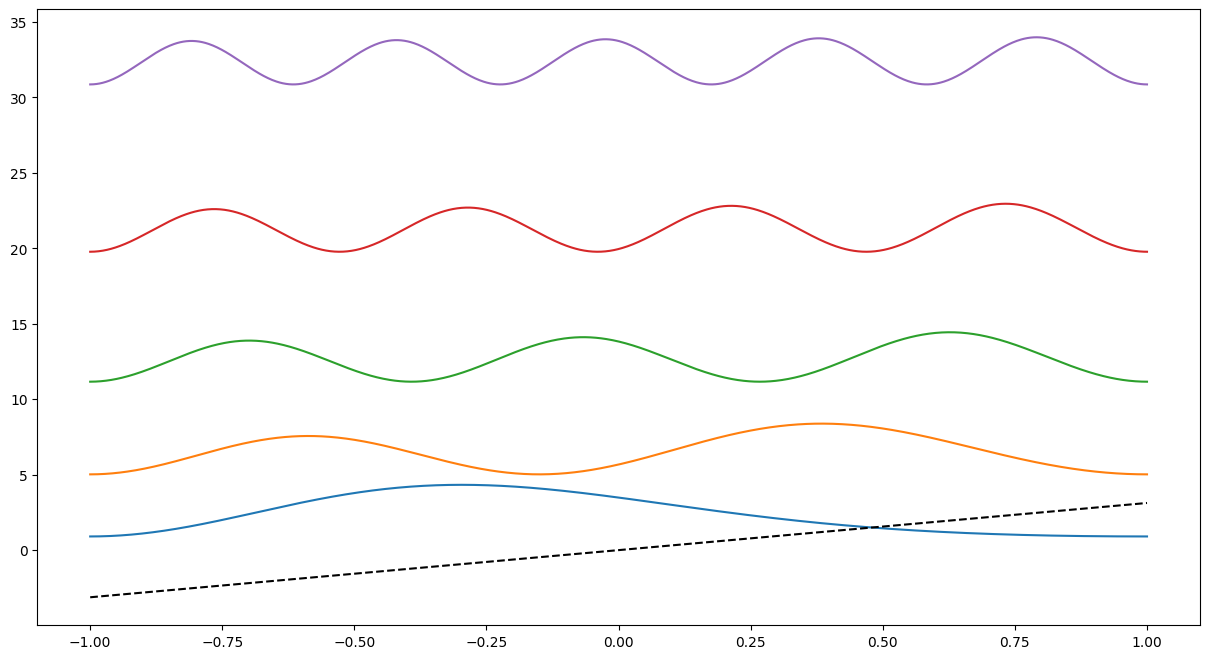

In [5]:
n = 20
field = 25./8
phi = get_basis(n)
x = np.linspace(-1, 1, 1000)
E, c = solve_secular_eq(phi,field)

for i in range(5):
    psi = get_wavefunction(phi,c[:,i])
    plt.plot(x, 3*psi(x)**2+E[i])

plt.plot(x, potential(field)(x), ls='--', c='black')
plt.show();

We can compute the (hyper)polarizabilities and dipole moment by using fitting the energy as a function of field to a polynomial. I.e., we fit the energy as:

$$
E(F) \approx a_0 + a_1 F + a_2 F^2 + a_3 F^3 + a_4 F^4 + \ldots
$$

and compare this to the definition of the dipole moment and the (hyper)polarizabilities

$$
E(F) = E(0) - \mu F - \tfrac{1}{2} \alpha F^2 - \tfrac{1}{3!} \beta F^3 - \tfrac{1}{4!} \gamma F^4 + \ldots
$$

In [6]:
def compute_polarizabilities(n,max_field):
    """
    Determine the dipole moment and (hyper)polarizabilities
    up to second order using energies up to max_field, with
    a basis set of size n. It is important to remember that
    the results can start to deteriorate if max_field is too large,
    but if max_field is too small numerical errors may make the
    computed hyperpolarizabilities inaccurate.

    Parameters:
    ----------
    n :: there are n+1 basis functions
    max_field :: the maximum field strength considered.
    """
    # Compute field values and g.s. energy values for each field.
    f_values = np.linspace(-1*max_field, max_field, 100)
    e0 = np.array([get_energies(n,f)[0] for f in f_values])
    p = Polynomial.fit(f_values,e0,4,domain=[-1,1])
    a4, a3, a2, a1, a0 = np.polyfit(f_values, e0, 4)
    print(p)
    #Take the coefficients of the polynomial and set them equal to the
    #dipole moment, polarizability, etc..
    E0    = a0
    mu    = -a1
    alpha = -2  * a2
    beta  = -6  * a3
    gamma = -24 * a4
     ### END YOUR CODE HERE
    #Plot the fit, just for fun.
    plt.plot(f_values, e0, 'o')
    xx,yy = p.linspace()
    plt.plot(xx, yy, lw=2)
    plt.show()

    return E0, mu, alpha, beta, gamma

1.2337005 + (2.2369982e-16)·x - 0.03511131·x² - (6.33752062e-16)·x³ +
0.00017882·x⁴


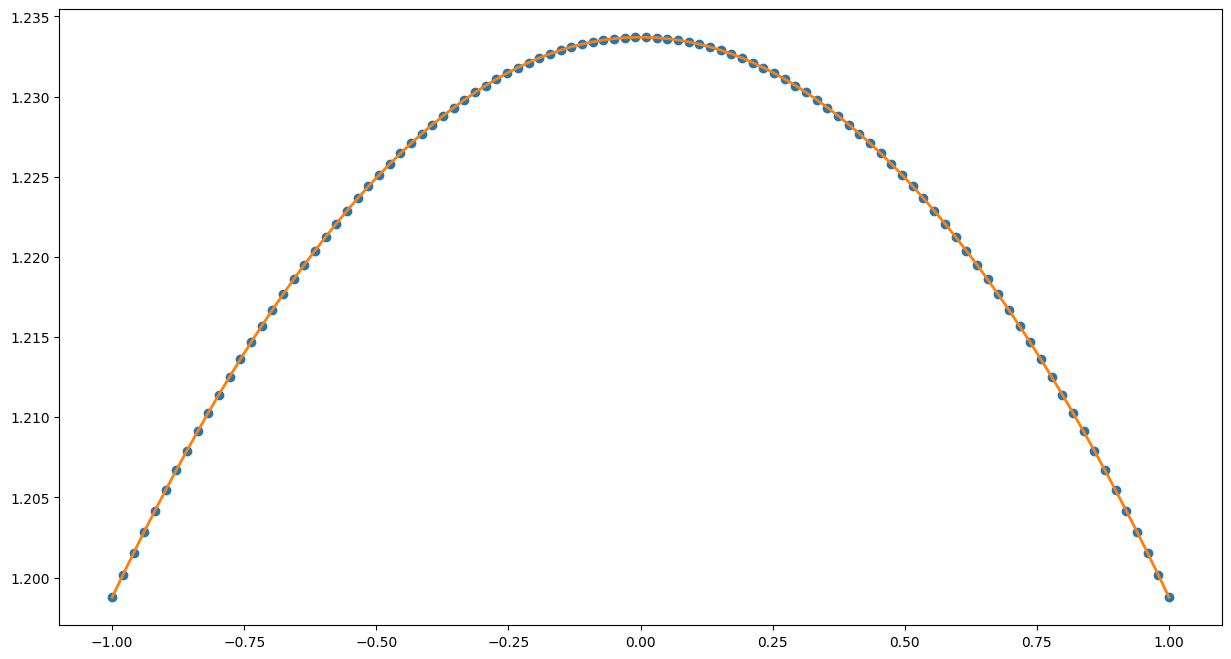

The unperturbed energy is:          1.2337004990320937
The dipole moment is:               -1.675351123308958e-17
The polarizability is:              0.07022262096786054
The first hyperpolarizability is:   1.3685418787312344e-15
The second hyperpolarizability is:  -0.004291617021244614


In [7]:
E0, mu, alpha, beta, gamma = compute_polarizabilities(10,1)
print("The unperturbed energy is:         ", E0)
print("The dipole moment is:              ", mu)
print("The polarizability is:             ", alpha)
print("The first hyperpolarizability is:  ", beta)
print("The second hyperpolarizability is: ", gamma)

### &#x1f914; Thought-Provoking Questions

- Why are the higher-energy eigenstates less sensitive to the perturbation than the lower-energy eigenstates?
- Why does it take more basis functions to converge the higher-energy eigenstates than the lower-energy eigenstates?
- Consider what happens for the following two quartic oscillators potentials below. The second of these has a dipole moment.
  - Explain the shape of the ground-state eigenfunctions.
  - When the perturbation is strong, the $V_1(x)$ has a nearly-degenerate ground-state. Why?

\begin{align}
V_1(x) &= F\left(1 - 200 x^2 + 10^4 x^4 \right) \\
V_2(x) &= F\left(1 + x - 200x^2 + 10^4 x^4 \right)
\end{align}

## &#x2696;&#xfe0f; Marking Scheme
&#x2611;&#xfe0f; Successful completion of the notebook, together with the ability to discuss your strategy, earns an **S**.  

&#x1f4b0; For an **S+**, answer the thought-provoking questions. Add markdown and code cells to complete these tasks. You can add images of hand-written answers to the markdown cells if you prefer, but write neatly.

### &#x1f914; **Answers**

- Why are the higher-energy eigenstates less sensitive to the perturbation than the lower-energy eigenstates?

For a particle in a tilted box, the perturbation is the linear potential $\hat{H}' = \lambda V(x)$.
Higher eigenstates have kinetic energies that scale as $E_n^{(0)} \propto n^2$, which rapidly
dominate over the perturbation $\lambda V$. When $E_n^{(0)} \gg \lambda V$,
the second-order correction:

$$E_n^{(2)} = \sum_{m \neq n} \frac{|\langle m^{(0)} | \lambda V | n^{(0)} \rangle|^2}{E_n^{(0)} - E_m^{(0)}}$$

becomes negligible, since the denominator grows as $n^2$ while the matrix elements grow much more slowly.

This is because the matrix elements take the form:

$$\langle m | x | n \rangle = \int_{-1}^{1} \psi_m(x) \cdot x \cdot \psi_n(x)\, dx$$

where $\psi_n(x) = \frac{1}{\sqrt{2}}\sin\left(\frac{n\pi(x+1)}{2}\right)$ carries no $n$-dependent amplitude and the prefactor $\frac{1}{\sqrt{2}}$ is constant for all $n$. Therefore, The matrix elements do not grow with $n$; innstead, they oscillate more rapidly.

The denominator, by contrast, grows unambiguously as: $$E_n^{(0)} - E_m^{(0)} \propto n^2 - m^2$$

In other words, it is this guaranteed polynomial growth in the denominator with no matching growth in the numerator that makes higher eigenstates increasingly insensitive to the perturbation. Intuitively, The wavefunction is thus well-described by the unperturbed eigenstate alone and the tilt of the box is essentially invisible to a particle moving fast enough.


- Why does it take more basis functions to converge the higher-energy eigenstates than the lower-energy eigenstates?

The $n$-th PIB eigenstate has $(n-1)$ nodes and completes $n/2$ periods within the box. Representing a function with more oscillations demands basis functions with higher-frequency components, by the same logic as a fourier series: a slowly varying function like $\psi_1$ converges with just a few low-frequency terms, while a rapidly oscillating function like $\psi_n$ requires many terms before the series faithfully captures all its features.

The number of basis functions needed is proportional with the number of nodes to be resolved. If the basis does not include functions with sufficient oscillation characteristics, no linear combination of smooth, low-frequency functions can accurately reconstruct a wavefunction that changes sign $(n-1)$ times. Notably, This is not a limitation of the variational method, it is a fundamental consequence of the spatial frequency of the target wavefunction.

- Consider what happens for the following two quartic oscillators potentials below. The second of these has a dipole moment.
  - Explain the shape of the ground-state eigenfunctions.
  - When the perturbation is strong, the $V_1(x)$ has a nearly-degenerate ground-state. Why?

\begin{align}
V_1(x) &= F\left(1 - 200 x^2 + 10^4 x^4 \right) \\
V_2(x) &= F\left(1 + x - 200x^2 + 10^4 x^4 \right)
\end{align}

### Shape of the Ground-State Eigenfunctions

Both $V_1$ and $V_2$ are solved on the domain $[-1, 1]$ with boundary
conditions $\psi(\pm 1) = 0$, making this a particle-in-a-box problem with the
polynomial potential acting as a perturbation. The ground-state kinetic energy
($E_0 \approx 30.8$) far exceeds the depth of the local minima ($\approx -1$
at $F = 0.01$), so the wavefunction is dominated by confinement rather than
localization near the minima. As a result, both $\psi_1$ and $\psi_2$ resemble
the first box eigenfunction, a single smooth arch, with only a subtle asymmetry
distinguishing them. The effect of the symmetry breaking in $V_2$ is best
captured by the polarizability coefficients: $\mu \approx 0$ for $V_1$
(symmetric) and $\mu \neq 0$ for $V_2$ (asymmetric), confirming that $V_2$
induces a nonzero permanent dipole moment in the ground state.

**As per the calculations in the code cells below.**

### Response to an External Field

The ground-state energy $E_0(f)$ is fit to a degree-4 polynomial in the field
strength $f$:

$$E_0(f) = E_0 - \mu f - \frac{1}{2}\alpha f^2 - \frac{1}{6}\beta f^3 - \frac{1}{24}\gamma f^4$$

For $V_1$, symmetry requires $\mu = 0$ and $\beta = 0$ — the energy is an even
function of $f$. For $V_2$, the broken symmetry allows $\mu \neq 0$ and
$\beta \neq 0$, reflecting the permanent dipole moment and first
hyperpolarizability of the asymmetric potential.

### Near-Degeneracy in $V_1$

In the absence of box confinement, a symmetric double-well potential such as
$V_1$ would exhibit a nearly-degenerate ground state when the local maximum at
$x = 0$ is large relative to the ground-state energy, as tunneling between the
two minima becomes exponentially suppressed. In our numerical setup, however,
this near-degeneracy is not observed: the energy difference between the ground
state and first excited state ($E_1 - E_0 \approx 92.5$) is large, and the
energy levels are evenly spaced as in a simple box. This is because the
ground-state kinetic energy ($E_0 \approx 30.8$) far exceeds the depth of the
local minima at the current value of $F$. Increasing $F$ does not recover this
effect — a strong field simply pushes the particle toward one boundary, as seen
in the wavefunction plot with $F = 5000$. To observe the near-degeneracy
numerically, the polynomial coefficients would need to be rescaled so that the
depth of the local minima is comparable to $E_0$.

N=40, F=0.01
E1[0:5]: [ 30.45421687 122.93289175 277.62287955 493.72406529 771.4077082 ]
E2[0:5]: [ 30.46421686 122.94289175 277.63287955 493.73406529 771.4177082 ]

N=40, F=50
E1[0:5]: [ 30.45421687 122.93289175 277.62287955 493.72406529 771.4077082 ]
E2[0:5]: [ 80.31379859 172.97535702 327.6473413  543.73924315 821.41783589]


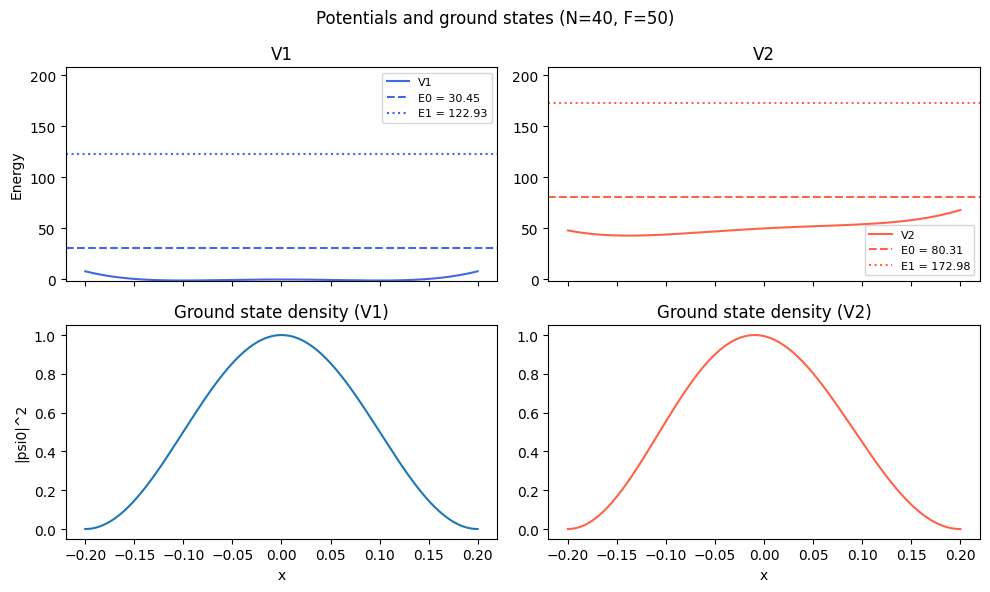

In [8]:
L = 0.2

# rescaled potentials
def potential_V1_scaled(t, f):
    x = L * t
    return -200*x**2 + 1e4*x**4

def potential_V2_scaled(t, f):
    x = L * t
    return (-200*x**2 + 1e4*x**4) + f*(1 + x)


# rescaled T matrix
def compute_t_scaled(phi, L):
    n = len(phi)
    t = np.zeros((n, n))
    for j in range(n):
        for k in range(n):
            phij_d2_phik = -1./(2*L**2) * phi[j] * phi[k].deriv(2)
            integral = phij_d2_phik.integ()
            t[j,k] = integral(1.0) - integral(-1.0)
    return t

def compute_v_custom(phi, pot_func, f):
    n = len(phi)
    v = np.zeros((n, n))
    t_grid = np.linspace(-1, 1, 500)
    pot_values = pot_func(t_grid, f)
    pot_poly = T.fit(t_grid, pot_values, deg=20)

    for j in range(n):
        for k in range(n):
            phij_v_phik = phi[j] * pot_poly * phi[k]
            integral = phij_v_phik.integ()
            v[j,k] = integral(1.0) - integral(-1.0)
    return v


def solve_secular_eq_custom(phi, pot_func, f):
    s = compute_s(phi)
    t = compute_t_scaled(phi, L)
    v = compute_v_custom(phi, pot_func, f)
    h = t + v
    E, c = eigh(h, s, subset_by_index=(0, len(phi)-1))
    return E, c


#basis and plotting grid
N  = 40
phi = get_basis(N)
t_plot = np.linspace(-1, 1, 500)
x_plot = L * t_plot

#solve at small field (reference)
F_ref = 0.01
E1_ref, c1_ref = solve_secular_eq_custom(phi, potential_V1_scaled, F_ref)
E2_ref, c2_ref = solve_secular_eq_custom(phi, potential_V2_scaled, F_ref)
print(f'N={N}, F={F_ref}')
print("E1[0:5]:", E1_ref[:5])
print("E2[0:5]:", E2_ref[:5])

#solve at large field (plotted case)
F = 50
E1, c1 = solve_secular_eq_custom(phi, potential_V1_scaled, F)
E2, c2 = solve_secular_eq_custom(phi, potential_V2_scaled, F)
print(f'\nN={N}, F={F}')
print("E1[0:5]:", E1[:5])
print("E2[0:5]:", E2[:5])

# potentials for plotting
v1_plot = potential_V1_scaled(t_plot, F)
v2_plot = potential_V2_scaled(t_plot, F)
v_ceil  = max(E1[1], E2[1]) * 1.2
v_floor = min(v1_plot.min(), v2_plot.min()) * 1.2
v1_clipped = np.clip(v1_plot, -np.inf, v_ceil)
v2_clipped = np.clip(v2_plot, -np.inf, v_ceil)

# ground state wavefunctions
psi1_vals = get_wavefunction(phi, c1[:, 0])(t_plot)
psi1_vals *= np.sign(psi1_vals[np.argmax(np.abs(psi1_vals))])

psi2_vals = get_wavefunction(phi, c2[:, 0])(t_plot)
psi2_vals *= np.sign(psi2_vals[np.argmax(np.abs(psi2_vals))])

# simple peak-normalized densities
prob1 = psi1_vals**2 / (psi1_vals**2).max()
prob2 = psi2_vals**2 / (psi2_vals**2).max()

# plots
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)

# V1
axes[0, 0].plot(x_plot, v1_clipped,color='royalblue', label='V1')
axes[0, 0].axhline(E1[0], color='royalblue', ls='--', label=f'E0 = {E1[0]:.2f}')
axes[0, 0].axhline(E1[1], color='royalblue', ls=':',  label=f'E1 = {E1[1]:.2f}')
axes[0, 0].set_ylim(v_floor, v_ceil)
axes[0, 0].set_ylabel('Energy')
axes[0, 0].set_title('V1')
axes[0, 0].legend(fontsize=8)

# V2
axes[0, 1].plot(x_plot, v2_clipped, color='tomato',label='V2')
axes[0, 1].axhline(E2[0], color='tomato',ls='--', label=f'E0 = {E2[0]:.2f}')
axes[0, 1].axhline(E2[1], color='tomato',ls=':',  label=f'E1 = {E2[1]:.2f}')
axes[0, 1].set_ylim(v_floor, v_ceil)
axes[0, 1].set_title('V2')
axes[0, 1].legend(fontsize=8)

# |psi0|^2 for V1
axes[1, 0].plot(x_plot, prob1)
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('|psi0|^2')
axes[1, 0].set_title('Ground state density (V1)')

# |psi0|^2 for V2
axes[1, 1].plot(x_plot, prob2,color='tomato')
axes[1, 1].set_xlabel('x')
axes[1, 1].set_title('Ground state density (V2)')

plt.suptitle(f'Potentials and ground states (N={N}, F={F})')
plt.tight_layout()
plt.show()

V1 (symmetric: expect mu=0, beta=0):


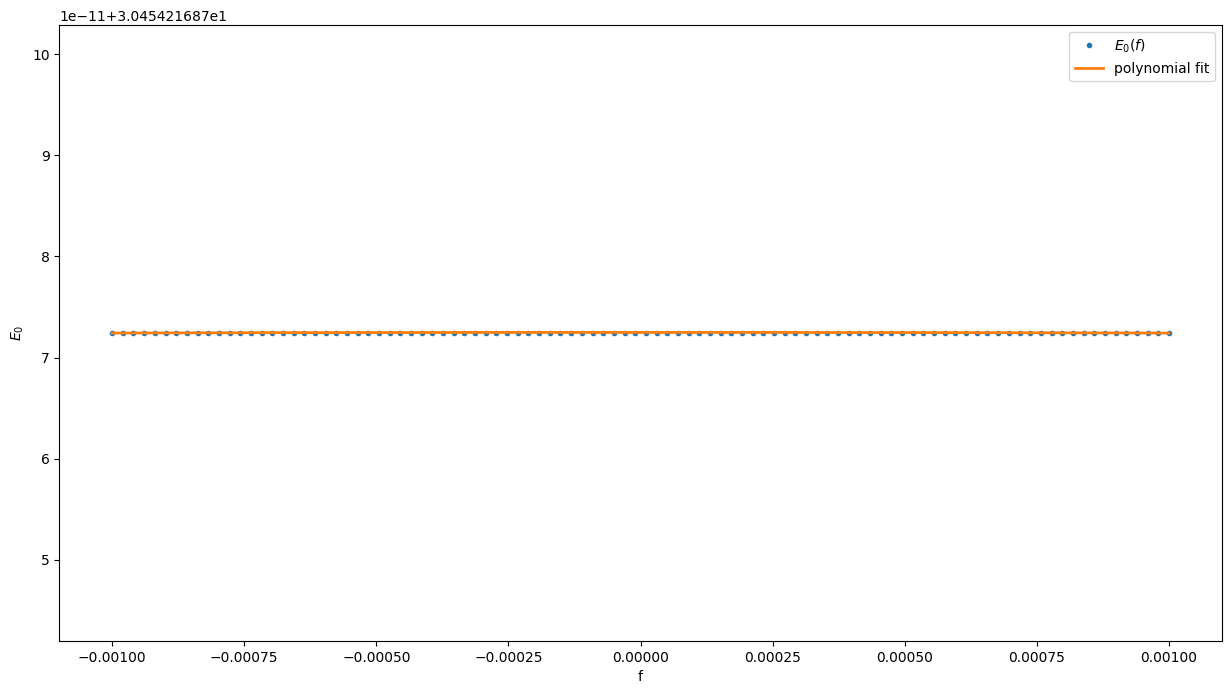

  mu = 0.000000,  alpha = 0.000000,  beta = -0.000000

V2 (asymmetric: expect mu≠0, beta≠0):


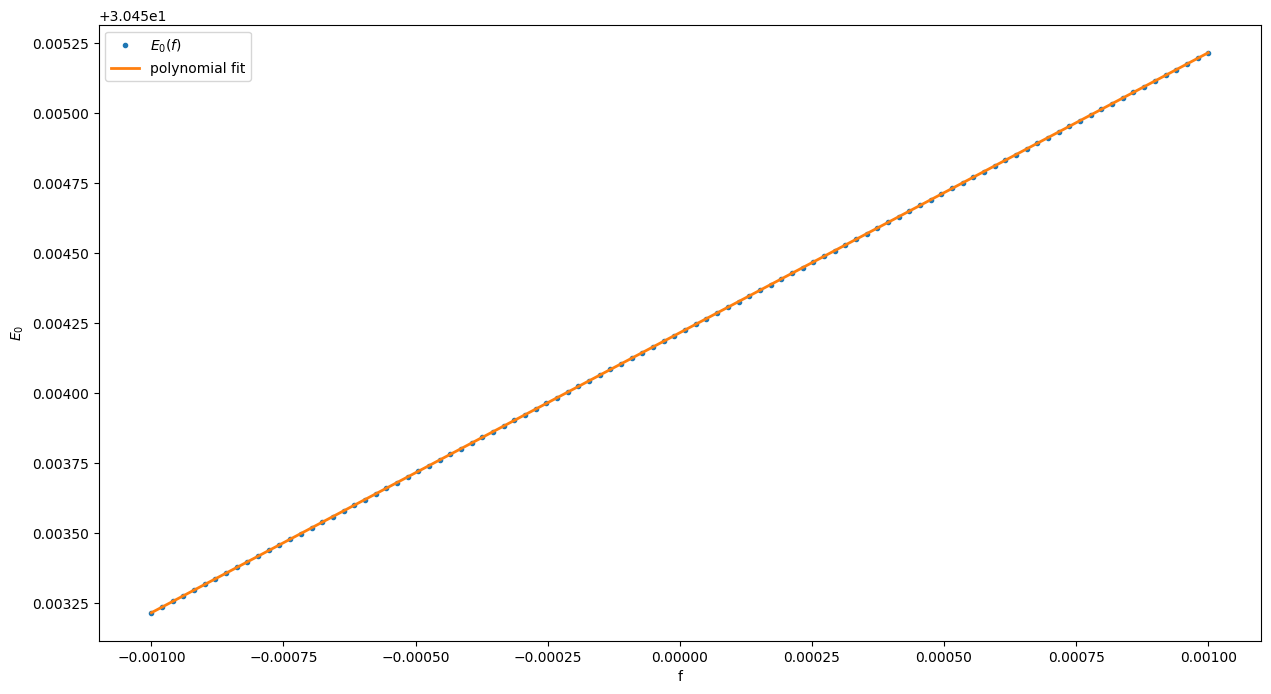

  mu = -1.000000,  alpha = 0.000112,  beta = -0.000613


In [9]:
def get_energies_custom(n, f, pot_func):
    phi = get_basis(n)
    eigenvalues, _ = solve_secular_eq_custom(phi, pot_func, f)
    return eigenvalues


def compute_polarizabilities_custom(n, max_field, pot_func):
    f_values = np.linspace(-max_field, max_field, 100)
    e0 = np.array([get_energies_custom(n, f, pot_func)[0] for f in f_values])

    a4, a3, a2, a1, a0 = np.polyfit(f_values, e0, 4)

    E0    = a0
    mu    = -a1
    alpha = -2  * a2
    beta  = -6  * a3
    gamma = -24 * a4

    plt.figure()
    plt.plot(f_values, e0, 'o', ms=3, label='$E_0(f)$')
    plt.plot(f_values, np.polyval([a4,a3,a2,a1,a0], f_values), lw=2, label='polynomial fit')
    plt.xlabel('f')
    plt.ylabel('$E_0$')
    plt.legend()
    plt.show()

    return E0, mu, alpha, beta, gamma


print("V1 (symmetric: expect mu=0, beta=0):")
E0, mu, alpha, beta, gamma = compute_polarizabilities_custom(40, 0.001, potential_V1_scaled)
print(f"  mu = {mu:.6f},  alpha = {alpha:.6f},  beta = {beta:.6f}")

print("\nV2 (asymmetric: expect mu≠0, beta≠0):")
E0, mu, alpha, beta, gamma = compute_polarizabilities_custom(40, 0.001, potential_V2_scaled)
print(f"  mu = {mu:.6f},  alpha = {alpha:.6f},  beta = {beta:.6f}")